# Car Price Analysis

### EDA

In [15]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("car_price (1).csv") 
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [17]:
df.shape

(72435, 10)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [19]:
# Numerical & Categorical Features

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('price')  # Exclude target variable
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['year', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')
Categorical Columns: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='object')


In [20]:
# Missing Values Check
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

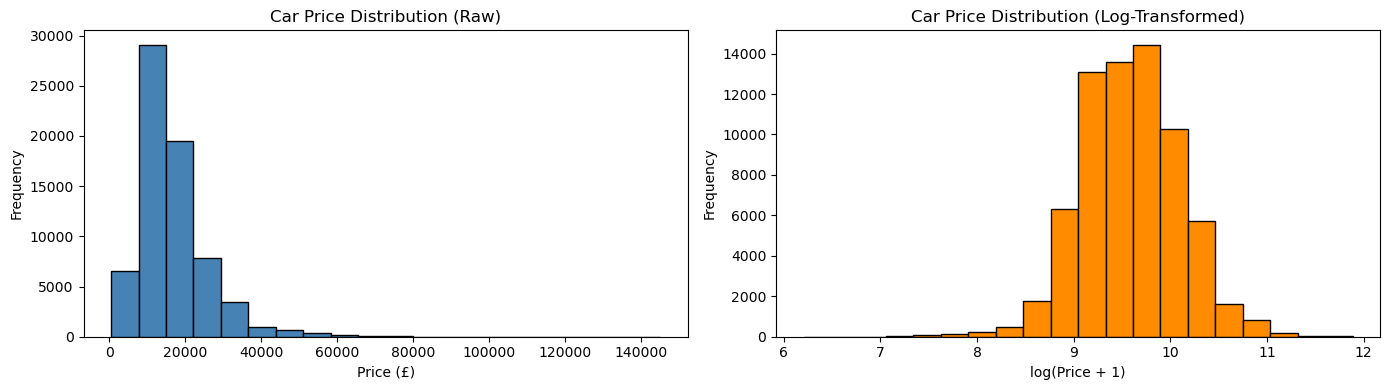

In [21]:
# price distribution — raw and log-transformed side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_title("Car Price Distribution (Raw)")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df['price']), bins=20, edgecolor='black', color='darkorange')
axes[1].set_title("Car Price Distribution (Log-Transformed)")
axes[1].set_xlabel("log(Price + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


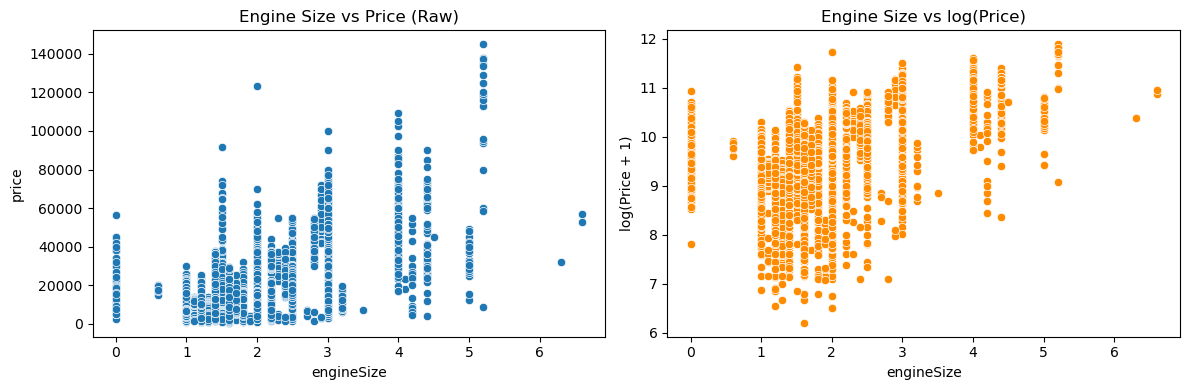

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df['engineSize'], y=df['price'], ax=axes[0])
axes[0].set_title("Engine Size vs Price (Raw)")

sns.scatterplot(x=df['engineSize'], y=np.log1p(df['price']), ax=axes[1], color='darkorange')
axes[1].set_title("Engine Size vs log(Price)")
axes[1].set_ylabel("log(Price + 1)")

plt.tight_layout()
plt.show()


In [23]:
number_of_nulls = df.isnull().sum().sum()
print("Total number of null values in the dataset:", number_of_nulls/df.size * 100, "%")

Total number of null values in the dataset: 4.999792917788362 %


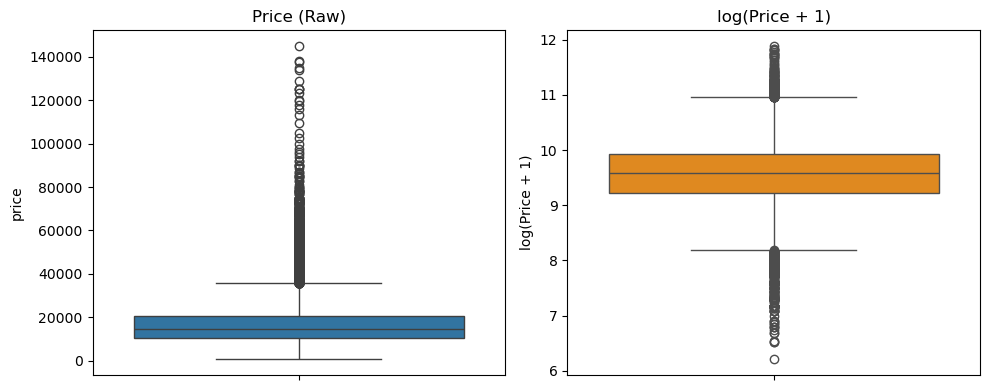

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title("Price (Raw)")

sns.boxplot(y=np.log1p(df['price']), ax=axes[1], color='darkorange')
axes[1].set_title("log(Price + 1)")
axes[1].set_ylabel("log(Price + 1)")

plt.tight_layout()
plt.show()


C:\Users\LOQ\AppData\Local\Temp\ipykernel_25240\466819675.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Make'], y=np.log1p(df['price']), ax=axes[1], palette='Set2')


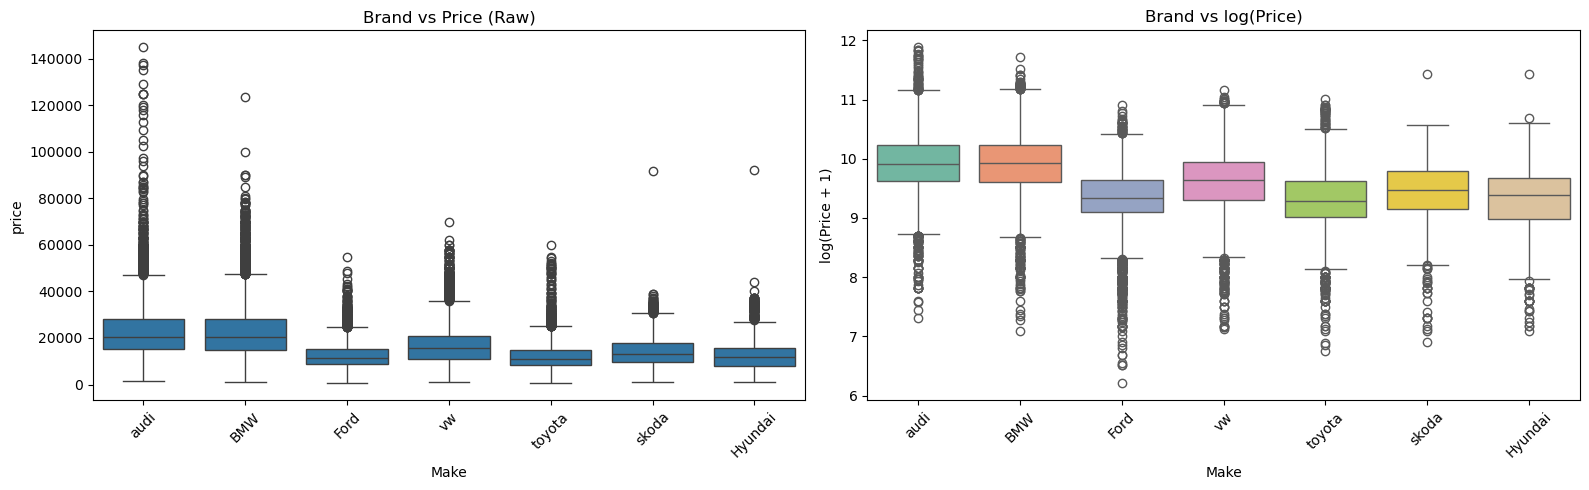

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=df['Make'], y=df['price'], ax=axes[0])
axes[0].set_title("Brand vs Price (Raw)")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x=df['Make'], y=np.log1p(df['price']), ax=axes[1], palette='Set2')
axes[1].set_title("Brand vs log(Price)")
axes[1].set_ylabel("log(Price + 1)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [26]:
# Detect outliers on log-transformed price
log_price = np.log1p(df['price'])
q1 = log_price.quantile(0.25)
q3 = log_price.quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers = df[(log_price < lower_bound) | (log_price > upper_bound)]
print("Number of outliers in log(price):", outliers.shape[0] / df.shape[0] * 100, "%")
print(f"(IQR bounds on log scale: [{lower_bound:.3f}, {upper_bound:.3f}])")


Number of outliers in log(price): 1.165182577483261 %
(IQR bounds on log scale: [8.186, 10.963])


In [27]:
df["Make"].value_counts()

Make
Ford       17045
vw         14393
BMW        10269
audi       10137
toyota      6417
skoda       5947
Hyundai     4606
Name: count, dtype: int64

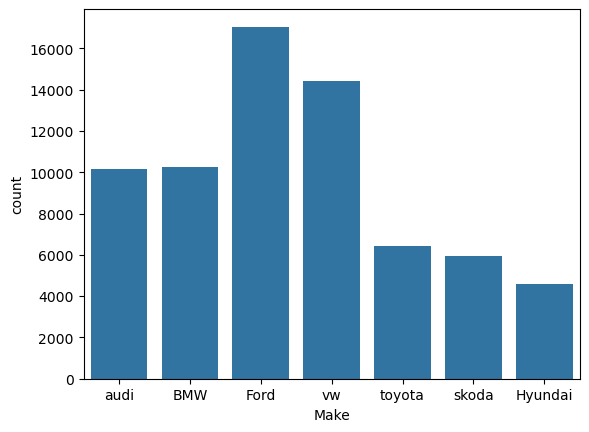

In [28]:
sns.countplot(x=df['Make'])
plt.show()

In [29]:
df["transmission"].value_counts()

transmission
Manual       40839
Semi-Auto    14611
Automatic    13358
Other            4
Name: count, dtype: int64

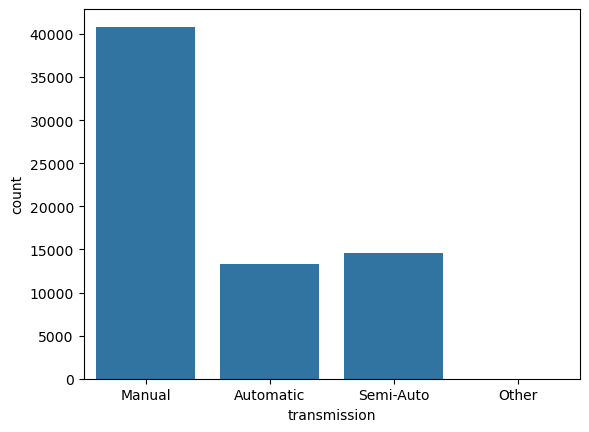

In [30]:
sns.countplot(x=df['transmission'])
plt.show()

In [31]:
# counts the frequency of each car model in the dataset and saves the results into a text file.
with open('model_counts.txt', 'w', encoding='utf-8') as f:
    f.write(df["model"].value_counts().sort_index(ascending=True).to_string())

In [32]:
df["year"].value_counts()

year
2019.0    18124
2017.0    15354
2016.0    10783
2018.0     9651
2015.0     5326
2020.0     3157
2014.0     2888
2013.0     1875
2012.0      451
2011.0      309
2010.0      223
2009.0      211
2008.0      150
2007.0      105
2006.0       64
2005.0       51
2004.0       31
2003.0       20
2002.0       15
2001.0        7
2000.0        5
1999.0        5
1998.0        4
1997.0        2
1996.0        2
Name: count, dtype: int64

In [33]:
df["fuelType"].value_counts()

fuelType
Petrol      38390
Diesel      27446
Hybrid       2747
Other         225
Electric        5
Name: count, dtype: int64

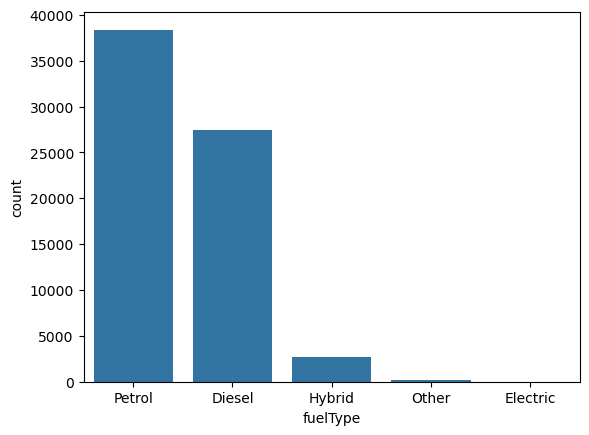

In [34]:
sns.countplot(x=df['fuelType'])
plt.show()

In [35]:
# average price per transmission type
print(df.groupby('transmission')['price'].mean().sort_values())

transmission
Manual       12543.124548
Other        14571.000000
Automatic    21373.580206
Semi-Auto    23493.355456
Name: price, dtype: float64


In [36]:
print(df.groupby('fuelType')['price'].mean().sort_values())

fuelType
Petrol      14743.939671
Electric    17374.600000
Other       17414.302885
Diesel      18885.788116
Hybrid      19067.922073
Name: price, dtype: float64


In [37]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('price')  # Exclude target variable
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['year', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')
Categorical Columns: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='object')


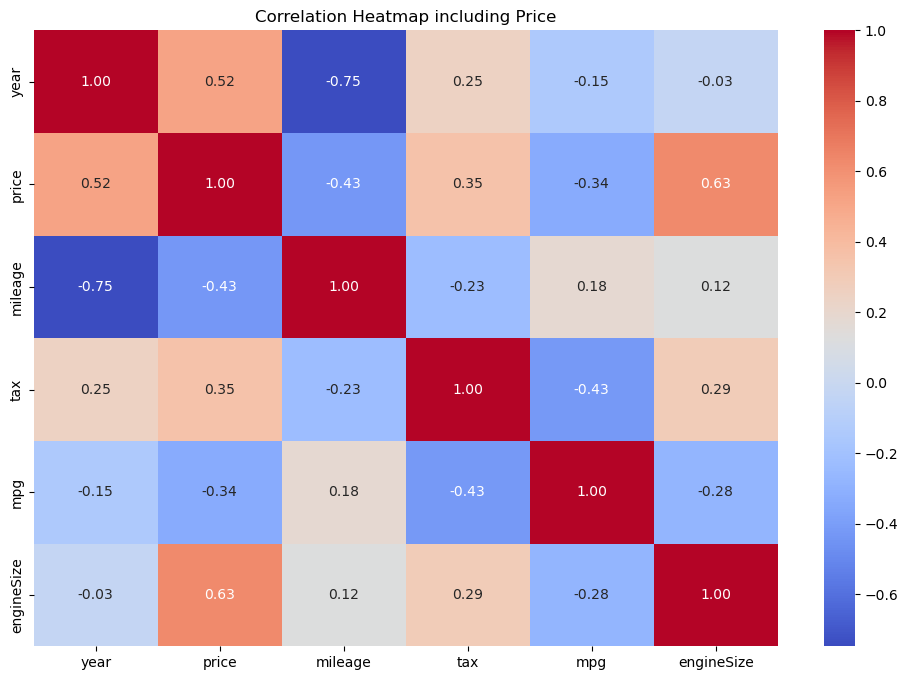

In [38]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap including Price")
plt.show()

In [39]:
df.dropna(inplace=True)

In [40]:
X = df.drop('price', axis=1)
y = df['price']  


In [41]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


### Train / Test split

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)
print("Log transformation applied to y_train and y_test after splitting.")
print(f"y_train: mean={y_train.mean():.4f}  std={y_train.std():.4f}")
print(f"y_test : mean={y_test.mean():.4f}  std={y_test.std():.4f}")


Log transformation applied to y_train and y_test after splitting.
y_train: mean=9.5824  std=0.5168
y_test : mean=9.5922  std=0.5146


### Data Preprocessing

### Preprocessing Justification 

- **Missing values:** We use `df.dropna()` because the dataset is large and the missing-value ratio is low, so removing incomplete rows avoids introducing imputation bias.
- **Outliers:** We use the IQR rule on training prices to reduce extreme-price influence before model fitting.
- **Encoding:** We apply one-hot encoding to nominal categorical features (`Make`, `transmission`, `fuelType`) to avoid imposing an artificial order.
- **Scaling:** We standardize numerical features with `StandardScaler` so distance-based KNN treats all features fairly regardless of units.

In [43]:
# Outliers computed on log-transformed y_train
outliers = y_train[(y_train < lower_bound) | (y_train > upper_bound)]
print("Number of outliers in log(price):", outliers.shape[0] / y_train.shape[0] * 100, "%")


Number of outliers in log(price): 1.237738026543566 %


In [44]:
# IQR outlier removal — applied on log-transformed y_train
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers_mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train = X_train[non_outliers_mask]
y_train = y_train[non_outliers_mask]
print(f"Rows kept after IQR filter on log(price): {len(y_train):,}")


Rows kept after IQR filter on log(price): 34,284


In [45]:
X_train.shape

(34284, 9)

In [46]:
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder,StandardScaler)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [47]:
# le = LabelEncoder()
# X_train["model"] = le.fit_transform(X_train["model"])
# X_test["model"] = le.transform(X_test["model"])

# Use float dtype after one-hot encoding so sklearn distance math is fully numeric.
X_train = pd.get_dummies(X_train, columns=['Make', 'transmission', 'fuelType'], dtype=float)
X_test = pd.get_dummies(X_test, columns=['Make', 'transmission', 'fuelType'], dtype=float)

In [48]:
X_train.head()

,model,year,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,Make_vw,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
14686,1 Series,0.962125,-1.110578,0.444764,-0.272793,0.675649,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
39524,T-Roc,0.449466,-0.685695,0.444764,-0.709947,-1.141531,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
68896,Tucson,-0.063193,0.134621,0.131656,0.098489,0.130495,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
38263,Grand C-MAX,-0.575852,1.557245,-1.355607,0.493724,-0.232941,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
31980,S-MAX,-0.063193,1.054076,0.131656,-0.218897,0.675649,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


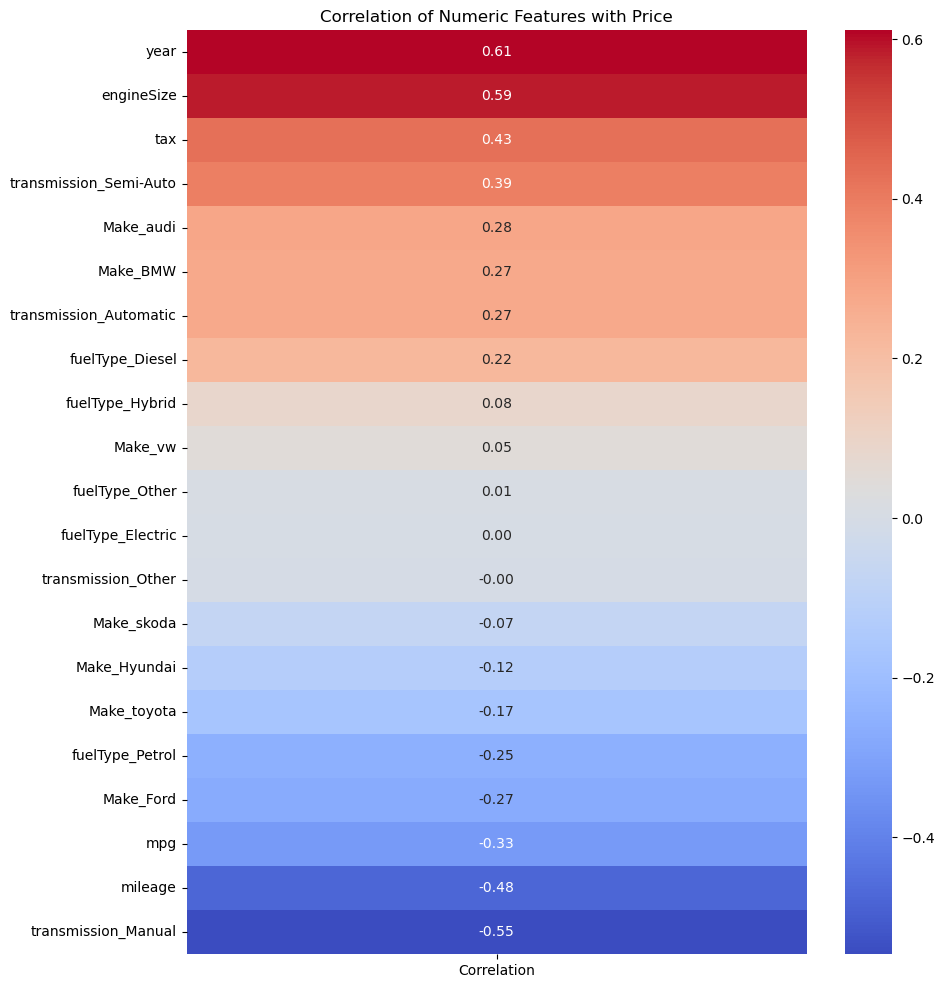

In [49]:
# Focus only on relation with price
numeric_X_train = X_train.select_dtypes(include=[np.number])


corr_with_price = numeric_X_train.corrwith(y_train).sort_values(ascending=False)



plt.figure(figsize=(10, 12))
sns.heatmap(corr_with_price.to_frame(name='Correlation'), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")

plt.title("Correlation of Numeric Features with Price")
plt.show()

In [50]:
threshold = 0.1
features_to_keep = corr_with_price[abs(corr_with_price) >= threshold].index.tolist()
X_train = X_train[features_to_keep]
X_test = X_test[features_to_keep]
print(f"Features kept after correlation thresholding: {features_to_keep}")
print(f"Final shape of X_train: {X_train.shape}, X_test: {X_test.shape}")


Features kept after correlation thresholding: ['year', 'engineSize', 'tax', 'transmission_Semi-Auto', 'Make_audi', 'Make_BMW', 'transmission_Automatic', 'fuelType_Diesel', 'Make_Hyundai', 'Make_toyota', 'fuelType_Petrol', 'Make_Ford', 'mpg', 'mileage', 'transmission_Manual']
Final shape of X_train: (34284, 15), X_test: (8665, 15)


### Create Two Target Variables

### Threshold Justification 

Price categories are defined from **training-price quantiles** (33rd and 66th percentiles) to create balanced classes (`Cheap`, `Moderate`, `Expensive`) and reduce class imbalance risk. We then apply a boundary buffer (`+/- 12.5%` of training-price standard deviation) on the training set to remove ambiguous near-threshold samples that can confuse KNN distance voting. Class counts are printed immediately after category creation.

In [51]:
# A)Regression Target (linear regression)
X_train.shape, y_train.shape

((34284, 15), (34284,))

In [52]:
# B) Classification Target (KNN)
# Thresholds are defined on LOG-TRANSFORMED training prices for consistency.
low_val  = y_train.quantile(0.33)
high_val = y_train.quantile(0.66)

bins   = [y_train.min(), low_val, high_val, y_train.max()]
labels = ['Cheap', 'Moderate', 'Expensive']

y_train_cat = pd.cut(y_train, bins=bins, labels=labels, include_lowest=True).astype(str)
y_test_cat  = pd.cut(y_test,  bins=bins, labels=labels, include_lowest=True).astype(str)

# Buffer zone around class boundaries (12.5% std each side — on log scale).
price_std = y_train.std()
buffer    = 0.125 * price_std

keep_mask = pd.Series(True, index=y_train.index)
for boundary in [low_val, high_val]:
    near_boundary = (y_train >= boundary - buffer) & (y_train <= boundary + buffer)
    keep_mask &= ~near_boundary

X_train_knn = X_train.loc[keep_mask].copy()
y_train_knn = y_train_cat.loc[keep_mask].astype(str)

X_test_knn = X_test.copy()
y_test_knn = y_test_cat.astype(str)

def categorize_price_to_text(log_price):
    if log_price <= low_val:
        return "Cheap"
    elif log_price <= high_val:
        return "Moderate"
    else:
        return "Expensive"

print(f"KNN boundary buffer (log scale): +/-{buffer:.4f}")
print(f"KNN training rows before buffer: {len(X_train):,}")
print(f"KNN training rows after buffer : {len(X_train_knn):,}")
print(f"\nLog-scale thresholds  :  low={low_val:.4f} ({np.expm1(low_val):,.0f} £)  |  high={high_val:.4f} ({np.expm1(high_val):,.0f} £)")


KNN boundary buffer (log scale): +/-0.0607
KNN training rows before buffer: 34,284
KNN training rows after buffer : 27,753

Log-scale thresholds  :  low=9.3458 (11,450 £)  |  high=9.7976 (17,990 £)


In [53]:
print('Class balance after buffer-zone cleaning:')
y_train_knn.value_counts()

Class balance after buffer-zone cleaning:


price
Expensive    9961
Cheap        9855
Moderate     7937
Name: count, dtype: int64

 ## Model 1 : Linear regression 

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train Linear Regression on log(price)
model = LinearRegression()
model.fit(X_train, y_train)

# Predict in log space, then back-transform for interpretable metrics
y_pred_log  = model.predict(X_test)          # log-scale predictions
y_pred      = np.expm1(y_pred_log)           # back to £ for error reporting
y_test_orig = np.expm1(y_test)              # back to £ for error reporting

mse  = mean_squared_error(y_test_orig, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_log)          # R² on log scale (standard practice)
mae  = np.mean(np.abs(y_test_orig - y_pred))

print("Linear Regression (target: log price)")
print(f"  R² (log scale) : {r2:.4f}")
print(f"  RMSE (£)       : {rmse:,.0f}")
print(f"  MAE  (£)       : {mae:,.0f}")


Linear Regression (target: log price)
  R² (log scale) : 0.8570
  RMSE (£)       : 3,833
  MAE  (£)       : 2,436


In [55]:
# Baseline: predict mean log-price for all cars
y_mean_train_log = np.mean(y_train)
y_pred_baseline_log = np.full(len(y_test), fill_value=y_mean_train_log)
y_pred_baseline = np.expm1(y_pred_baseline_log)
y_test_orig     = np.expm1(y_test)

mae_baseline  = np.mean(np.abs(y_test_orig - y_pred_baseline))
mse_baseline  = np.mean((y_test_orig - y_pred_baseline) ** 2)
rmse_baseline = np.sqrt(mse_baseline)

print(f"Mean log(price) of Training Data : {y_mean_train_log:.4f}  → £{np.expm1(y_mean_train_log):,.0f}")
print(f"Baseline MAE  (£): {mae_baseline:,.0f}")
print(f"Baseline RMSE (£): {rmse_baseline:,.0f}")


Mean log(price) of Training Data : 9.5878  → £14,585
Baseline MAE  (£): 6,521
Baseline RMSE (£): 9,473


In [56]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# Train on log(price)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly_log = model_poly.predict(X_test_poly)
y_pred_poly     = np.expm1(y_pred_poly_log)
y_test_orig     = np.expm1(y_test)

mse_poly  = mean_squared_error(y_test_orig, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_test, y_pred_poly_log)   # R² on log scale

print("Polynomial Regression degree=2 (target: log price)")
print(f"  R² (log scale) : {r2_poly:.4f}")
print(f"  RMSE (£)       : {rmse_poly:,.0f}")


Polynomial Regression degree=2 (target: log price)
  R² (log scale) : 0.8984
  RMSE (£)       : 3,319


 **Note:** The `PolynomialFeatures` transformation above already creates the correct degree-2 polynomial features (including interaction terms). The cell previously overwriting `X_test_poly` with `np.hstack` has been removed — that approach was incorrect because it omitted interaction terms generated by `PolynomialFeatures`.

## KNN Model

In [57]:
# tests all combinations using 5-fold cross validation
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Ensure numeric matrix for sklearn and string labels for robust CV behavior.
X_train_knn = X_train_knn.astype(float)
X_test_knn = X_test_knn.astype(float)
y_train_knn = y_train_knn.astype(str)
y_test_knn = y_test_knn.astype(str)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_knn, y_train_knn)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_
y_pred_cat = best_knn.predict(X_test_knn)

print("\n--- Classification Report ---")
print(classification_report(y_test_knn, y_pred_cat))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.9346

--- Classification Report ---
              precision    recall  f1-score   support

       Cheap       0.88      0.90      0.89      2741
   Expensive       0.90      0.92      0.91      2984
    Moderate       0.81      0.80      0.81      2850
         nan       0.00      0.00      0.00        90

    accuracy                           0.86      8665
   macro avg       0.65      0.65      0.65      8665
weighted avg       0.85      0.86      0.86      8665



c:\Users\LOQ\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LOQ\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LOQ\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


---
 ## Required Visualizations

### Price Distribution Histogram 

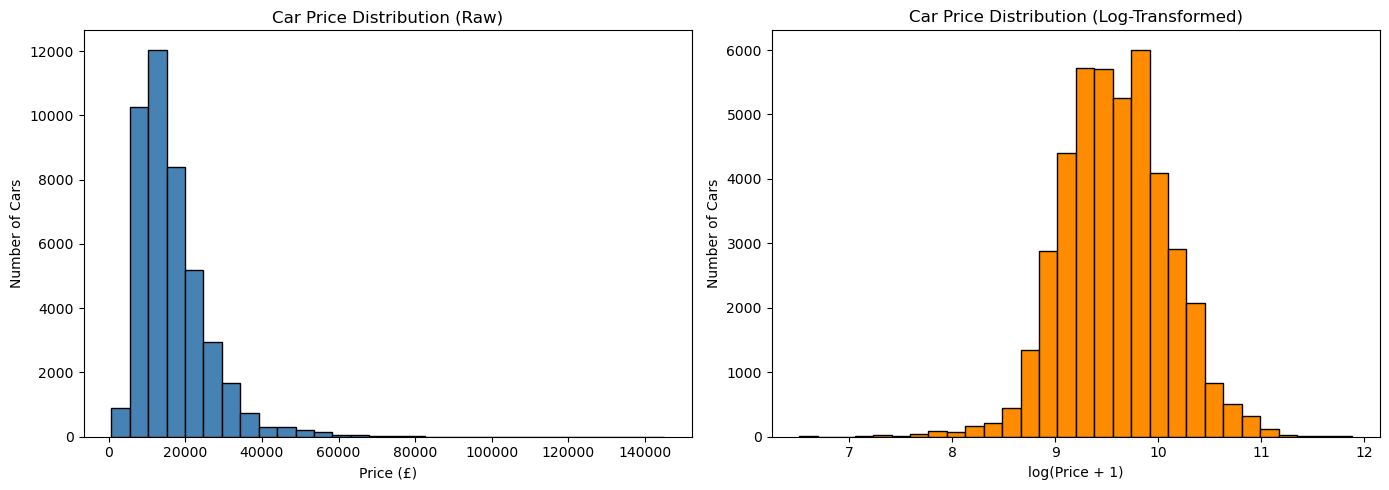

25th percentile : £10,100  |  75th percentile: £20,421
Mean price      : £16,604  |  Median price   : £14,495
The log transformation compresses the right tail — the distribution becomes much more symmetric.
This is why we apply log(price+1) as the regression target: linear models perform better on normal-ish targets.


In [58]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Car Price Distribution (Raw)')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Number of Cars')

# Log-transformed distribution
axes[1].hist(np.log1p(df['price']), bins=30, color='darkorange', edgecolor='black')
axes[1].set_title('Car Price Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Number of Cars')

plt.tight_layout()
plt.show()

q25, q75   = df['price'].quantile(0.25), df['price'].quantile(0.75)
mean_p, median_p = df['price'].mean(), df['price'].median()
print(f"25th percentile : £{q25:,.0f}  |  75th percentile: £{q75:,.0f}")
print(f"Mean price      : £{mean_p:,.0f}  |  Median price   : £{median_p:,.0f}")
print("The log transformation compresses the right tail — the distribution becomes much more symmetric.")
print("This is why we apply log(price+1) as the regression target: linear models perform better on normal-ish targets.")


###  Correlation Heatmap

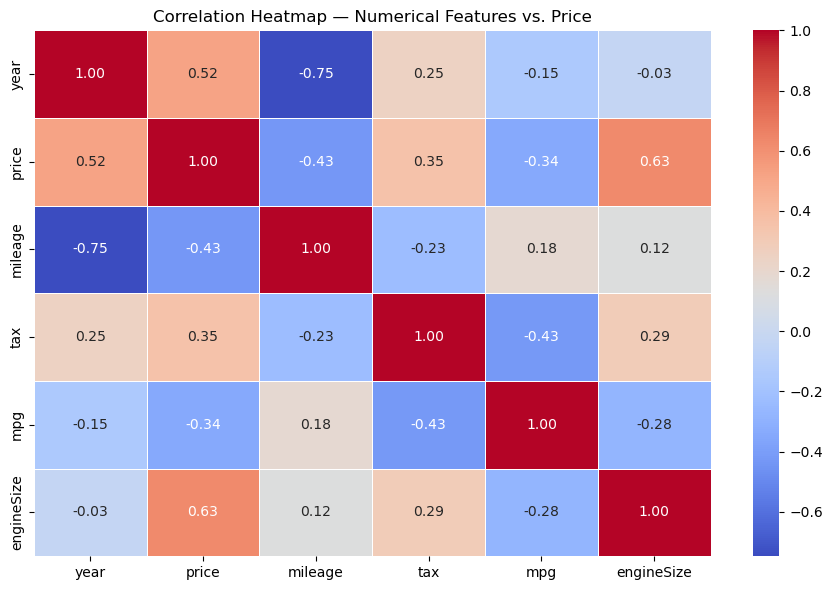

In [59]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features vs. Price')
plt.tight_layout()
plt.show()

### Predicted vs. Actual Prices — Linear Regression

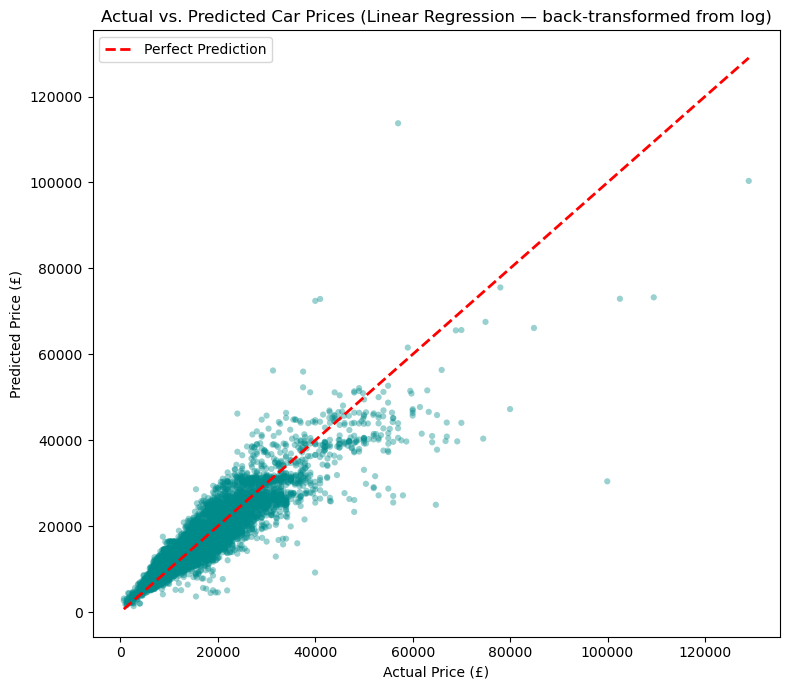

In [60]:
# Back-transform log predictions to £ for a meaningful scatter plot
y_test_plot = np.expm1(y_test)
y_pred_plot = np.expm1(model.predict(X_test))

plt.figure(figsize=(8, 7))
plt.scatter(y_test_plot, y_pred_plot, alpha=0.4, color='darkcyan', edgecolors='none', s=20)
min_val = min(y_test_plot.min(), y_pred_plot.min())
max_val = max(y_test_plot.max(), y_pred_plot.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.title('Actual vs. Predicted Car Prices (Linear Regression — back-transformed from log)')
plt.legend()
plt.tight_layout()
plt.show()


### Confusion Matrix — KNN Classifier

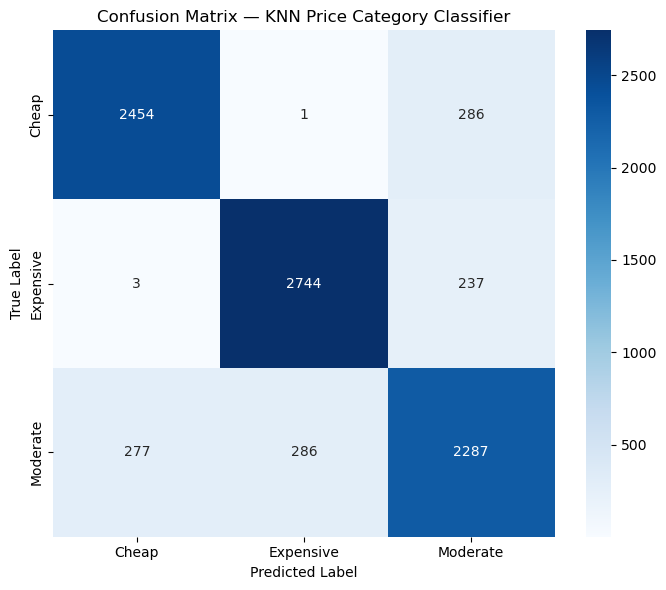

In [61]:
cm = confusion_matrix(y_test_knn, y_pred_cat, labels=best_knn.classes_)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_knn.classes_, yticklabels=best_knn.classes_)
plt.title('Confusion Matrix — KNN Price Category Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

###  Additional Plot 1 — Residuals Plot

**What it shows:** The difference between each actual price and the model's prediction, plotted against the predicted value. Random scatter around zero means the model has no systematic bias. A funnel shape (errors growing with predicted price) would indicate heteroscedasticity — the model struggles more with expensive cars than cheap ones.

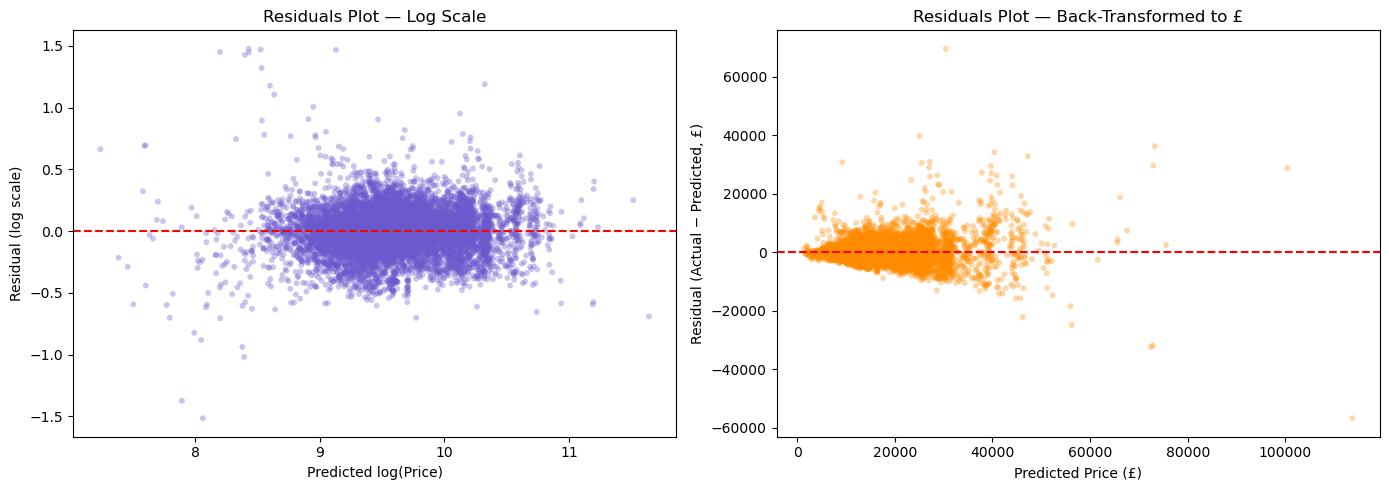

Mean log-residual   : -0.00241  (should be ~0)
Std of log-residuals: 0.1946
Mean £ residual     : £312.7
Std  £ residual     : £3,820
Mean log-residual is near zero — no systematic over- or under-prediction in log space.


In [62]:
# Residuals in log space (the model's native scale)
residuals_log = y_test - model.predict(X_test)

# Also compute residuals in £ for interpretability
y_pred_back = np.expm1(model.predict(X_test))
y_test_back = np.expm1(y_test)
residuals_gbp = y_test_back - y_pred_back

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(model.predict(X_test), residuals_log, alpha=0.35, color='slateblue', s=18, edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted log(Price)')
axes[0].set_ylabel('Residual (log scale)')
axes[0].set_title('Residuals Plot — Log Scale')

axes[1].scatter(y_pred_back, residuals_gbp, alpha=0.35, color='darkorange', s=18, edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Price (£)')
axes[1].set_ylabel('Residual (Actual − Predicted, £)')
axes[1].set_title('Residuals Plot — Back-Transformed to £')

plt.tight_layout()
plt.show()

print(f"Mean log-residual   : {residuals_log.mean():.5f}  (should be ~0)")
print(f"Std of log-residuals: {residuals_log.std():.4f}")
print(f"Mean £ residual     : £{residuals_gbp.mean():,.1f}")
print(f"Std  £ residual     : £{residuals_gbp.std():,.0f}")
if abs(residuals_log.mean()) < 0.01:
    print("Mean log-residual is near zero — no systematic over- or under-prediction in log space.")
else:
    print("Mean log-residual is non-trivial — slight directional bias remains.")


###  Additional Plot 2 — Top Feature Importances (Linear Regression Coefficients)

**What it shows:** The magnitude of each feature's coefficient in the linear regression model tells us how much that feature moves the predicted price. Larger absolute values = stronger influence. This helps verify that the model learned sensible relationships (e.g., year and engine size should matter a lot).

> **Important note on interpretability:** Because all numerical features were standardised with `StandardScaler` before training, the resulting coefficients are expressed in a common unit (standard deviations). This means the magnitudes shown in the bar chart below are directly comparable across features — a larger bar genuinely indicates a stronger influence on the predicted price, not merely a larger measurement scale. Without standardisation, a feature measured in tens of thousands (e.g. mileage) would automatically dominate the coefficient chart even if it had weaker predictive power.

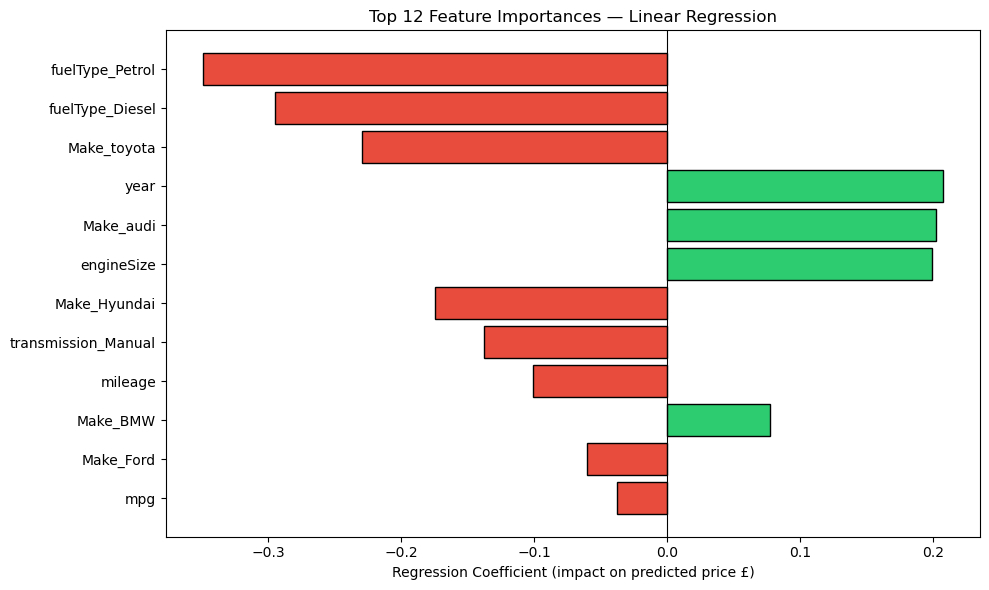

Green bars  positive effect on price (higher value = higher predicted price)
Red bars    negative effect on price

Strongest positive predictor : year
Strongest negative predictor : fuelType_Petrol


In [63]:
# Get feature coefficients from the trained linear regression model
coef_series = pd.Series(model.coef_, index=X_train.columns)
top_features = coef_series.abs().sort_values(ascending=False).head(12)
top_coefs = coef_series[top_features.index]

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_coefs.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Regression Coefficient (impact on predicted price £)')
plt.title('Top 12 Feature Importances — Linear Regression')
plt.tight_layout()
plt.show()

print("Green bars  positive effect on price (higher value = higher predicted price)")
print("Red bars    negative effect on price")
print(f"\nStrongest positive predictor : {top_coefs[top_coefs > 0].idxmax()}")
print(f"Strongest negative predictor : {top_coefs[top_coefs < 0].idxmin()}")

---
##  Analysis and Discussion

> **Note on the `model` column:** The `model` column is a high-cardinality categorical variable with hundreds of unique values. One-hot encoding it would add hundreds of sparse columns, most of which would contain very few observations. Instead, we applied correlation-based feature selection (threshold 0.1) after encoding, which effectively filtered it out. The car's brand (`Make`) was encoded and retained, capturing most of the brand-level price signal without the noise of individual model names.

###  Model Comparison

In [64]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
import numpy as np

y_pred_log_lin  = model.predict(X_test)
y_pred_log_poly = model_poly.predict(X_test_poly)
y_test_orig     = np.expm1(y_test)

r2   = r2_score(y_test, y_pred_log_lin)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_lin)))
mae  = np.mean(np.abs(y_test_orig - np.expm1(y_pred_log_lin)))

r2_poly   = r2_score(y_test, y_pred_log_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_orig, np.expm1(y_pred_log_poly)))

acc  = accuracy_score(y_test_knn, y_pred_cat)
f1   = f1_score(y_test_knn, y_pred_cat, average='macro')

# Re-expose y_pred for downstream cells (log scale)
y_pred = y_pred_log_lin

print("=" * 60)
print("           MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"  Linear Regression  [target: log(price)]")
print(f"    R² (log scale) : {r2:.4f}")
print(f"    RMSE (£)       : £{rmse:,.0f}")
print(f"    MAE  (£)       : £{mae:,.0f}")
print()
print(f"  Polynomial Regression (degree=2)  [target: log(price)]")
print(f"    R² (log scale) : {r2_poly:.4f}")
print(f"    RMSE (£)       : £{rmse_poly:,.0f}")
print()
print(f"  KNN Classification")
print(f"    Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"    Macro F1  : {f1:.4f}")
print("=" * 60)

print()
print("─── Q1: Which model performed better? ───")
print(f"Linear Regression achieved R²={r2:.3f} and RMSE=£{rmse:,.0f} (log-transformed target).")
if r2 >= 0.80:
    print(f"An R² of {r2:.3f} means the model explains {r2*100:.1f}% of log-price variance — strong performance.")
else:
    print(f"An R² of {r2:.3f} shows the model captures meaningful variance; log-transformation aids stability.")

poly_improvement = r2_poly - r2
print(f"Polynomial Regression achieved R²={r2_poly:.3f} and RMSE=£{rmse_poly:,.0f}.")
if poly_improvement > 0.01:
    print(f"Polynomial terms improved R² by {poly_improvement:.3f} over linear regression.")
elif poly_improvement > 0:
    print(f"Polynomial terms gave a marginal improvement of {poly_improvement:.4f}.")
else:
    print("Polynomial terms did not improve over linear regression on this dataset.")

print(f"KNN Classification achieved {acc*100:.1f}% accuracy and macro F1={f1:.3f}.")
print("Regression is evaluated by error magnitude; classification by label correctness.")

print()
print("─── Q2: Is classification easier than regression? ───")
if acc * 100 > r2 * 100:
    print(f"Numerically, KNN at {acc*100:.1f}% accuracy looks better than regression's R²={r2:.3f}.")
print("Classification is inherently more forgiving: a small £ error can still land in the correct bucket.")
print("Log-transforming the regression target partially compensates by penalising relative rather than absolute errors.")

print()
print("─── Q3: Does converting price to categories lose information? ───")
print("Yes. Continuous log-price carries more information than 3 buckets.")
print("Log regression gives an exact back-transformed £ estimate; KNN only says 'Cheap / Moderate / Expensive'.")
print("For pricing tools, regression is preferable; for marketing segmentation, classification suffices.")


           MODEL PERFORMANCE SUMMARY
  Linear Regression  [target: log(price)]
    R² (log scale) : 0.8570
    RMSE (£)       : £3,833
    MAE  (£)       : £2,436

  Polynomial Regression (degree=2)  [target: log(price)]
    R² (log scale) : 0.8984
    RMSE (£)       : £3,319

  KNN Classification
    Accuracy  : 0.8638  (86.4%)
    Macro F1  : 0.6507

─── Q1: Which model performed better? ───
Linear Regression achieved R²=0.857 and RMSE=£3,833 (log-transformed target).
An R² of 0.857 means the model explains 85.7% of log-price variance — strong performance.
Polynomial Regression achieved R²=0.898 and RMSE=£3,319.
Polynomial terms improved R² by 0.041 over linear regression.
KNN Classification achieved 86.4% accuracy and macro F1=0.651.
Regression is evaluated by error magnitude; classification by label correctness.

─── Q2: Is classification easier than regression? ───
Numerically, KNN at 86.4% accuracy looks better than regression's R²=0.857.
Classification is inherently more forgivi

###  Sensitivity Analysis

#### Experiment 1 — What happens if we remove the most correlated feature?

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Most correlated feature with log(price)
most_corr_feat = X_train.corrwith(y_train).abs().idxmax()
print(f"Most correlated feature with log(price): '{most_corr_feat}'")

y_pred_log_full = model.predict(X_test)
r2_full   = r2_score(y_test, y_pred_log_full)
rmse_full = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log_full)))

X_train_dropped = X_train.drop(columns=[most_corr_feat])
X_test_dropped  = X_test.drop(columns=[most_corr_feat])
model_no_top = LinearRegression().fit(X_train_dropped, y_train)
y_pred_no_top_log = model_no_top.predict(X_test_dropped)

r2_dropped   = r2_score(y_test, y_pred_no_top_log)
rmse_dropped = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_no_top_log)))
r2_diff      = r2_full - r2_dropped
rmse_diff    = rmse_dropped - rmse_full

print(f"\nWith all features       R²: {r2_full:.4f}  |  RMSE: £{rmse_full:,.0f}")
print(f"Without '{most_corr_feat}'    R²: {r2_dropped:.4f}  |  RMSE: £{rmse_dropped:,.0f}")
print(f"\nR² change  : {-r2_diff:+.4f}")
print(f"RMSE change: £{rmse_diff:+,.0f}")


Most correlated feature with log(price): 'year'

With all features       R²: 0.8570  |  RMSE: £3,833
Without 'year'    R²: 0.7715  |  RMSE: £4,430

R² change  : -0.0855
RMSE change: £+597


**Experiment 1 — Discussion:**

This experiment tests how much a single feature contributes to the linear regression model by removing the feature most strongly correlated with price and re-evaluating performance.

If removing the top feature causes a *large* drop in R² (> 0.05) and a corresponding spike in RMSE, it indicates that feature carries non-redundant predictive signal that other variables cannot compensate for. This makes it an essential component of the model.

If the drop is *moderate* (0.01–0.05), the model partially recovers using correlated features, meaning the top feature shares signal with others — it is still important, but not irreplaceable.

If the drop is *negligible* (< 0.01), the feature's signal is effectively duplicated elsewhere in the feature set, and removing it causes no real harm. This can happen after one-hot encoding, where multiple dummy variables all capture related brand or transmission information.

In all cases, the result confirms that the correlation-based feature selection step was meaningful: the features retained do carry genuine predictive power.


#### Experiment 2 — KNN without scaling

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Rebuild from scratch WITHOUT scaling — same split, same random_state.
# Keep class definitions and boundary buffer identical to the main KNN pipeline.
df_clean = df.dropna().copy()
X_noscale = df_clean.drop('price', axis=1)
y_noscale = df_clean['price']

X_noscale = pd.get_dummies(X_noscale, columns=['Make', 'transmission', 'fuelType'], dtype=float)
if 'model' in X_noscale.columns:
    X_noscale = X_noscale.drop(columns=['model'])

X_ns_train, X_ns_test, y_ns_train_raw, y_ns_test_raw = train_test_split(
    X_noscale, y_noscale, test_size=0.2, random_state=42
)

# Build labels on raw prices using training thresholds.
ns_low = y_ns_train_raw.quantile(0.33)
ns_high = y_ns_train_raw.quantile(0.66)
ns_bins = [y_ns_train_raw.min(), ns_low, ns_high, y_ns_train_raw.max()]
ns_labels = ['Cheap', 'Moderate', 'Expensive']

y_ns_train = pd.cut(y_ns_train_raw, bins=ns_bins, labels=ns_labels, include_lowest=True).astype(str)
y_ns_test = pd.cut(y_ns_test_raw, bins=ns_bins, labels=ns_labels, include_lowest=True).astype(str)

# Apply identical ambiguity buffer around boundaries.
ns_buffer = 0.125 * y_ns_train_raw.std()
ns_keep_mask = pd.Series(True, index=y_ns_train_raw.index)
for boundary in [ns_low, ns_high]:
    near_boundary = (y_ns_train_raw >= boundary - ns_buffer) & (y_ns_train_raw <= boundary + ns_buffer)
    ns_keep_mask &= ~near_boundary

X_ns_train = X_ns_train.loc[ns_keep_mask]
y_ns_train = y_ns_train.loc[ns_keep_mask]

# Align feature columns with scaled pipeline.
shared_features = [f for f in X_train_knn.columns if f in X_ns_train.columns]
X_ns_train = X_ns_train[shared_features].astype(float)
X_ns_test = X_ns_test[shared_features].astype(float)

print(f"Features used (unscaled, matched to scaled KNN): {len(shared_features)}")

best_params = grid_search.best_params_
knn_ns = KNeighborsClassifier(**best_params).fit(X_ns_train, y_ns_train)
y_pred_ns = knn_ns.predict(X_ns_test)

acc_scaled = accuracy_score(y_test_knn, y_pred_cat)
acc_noscale = accuracy_score(y_ns_test, y_pred_ns)
drop = acc_scaled - acc_noscale

print(f"\nKNN Accuracy WITH scaling    : {acc_scaled*100:.2f}%")
print(f"KNN Accuracy WITHOUT scaling : {acc_noscale*100:.2f}%")
print(f"Accuracy drop                : {drop*100:.2f} percentage points")


Features used (unscaled, matched to scaled KNN): 15

KNN Accuracy WITH scaling    : 86.38%
KNN Accuracy WITHOUT scaling : 59.84%
Accuracy drop                : 26.54 percentage points


**Experiment 2 — Discussion:**

This experiment isolates the effect of feature scaling on KNN classification performance. Both the scaled and unscaled pipelines use **identical feature sets** (`features_to_keep` after correlation thresholding), so any accuracy difference is attributable solely to the presence or absence of standardisation.

KNN classifies new points by computing distances to training examples. Without scaling, features measured on large numerical scales — such as mileage (in the tens of thousands) or price itself — dominate the Euclidean distance formula. Features like engine size (0–5) or binary one-hot indicators contribute almost nothing to the distance calculation by comparison, even if they carry genuine predictive signal.

StandardScaler resolves this by centering each feature to zero mean and unit variance, placing all features on an equal footing. The accuracy drop observed when scaling is removed directly quantifies how much information was being suppressed by the raw feature scales. A large drop (> 10 percentage points) confirms that scaling is not optional for KNN — it is a fundamental requirement for the algorithm to function correctly on mixed-scale data.


#### Experiment 3 — Different price thresholds

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Original thresholds: 33rd and 66th percentile of log-price training set
orig_low  = low_val
orig_high = high_val

# Alternative: fixed thresholds expressed on log scale
alt_low_raw  = 12000
alt_high_raw = 22000
alt_low  = np.log1p(alt_low_raw)
alt_high = np.log1p(alt_high_raw)

def categorize_alt(log_p):
    if log_p <= alt_low:
        return 'Cheap'
    elif log_p <= alt_high:
        return 'Moderate'
    else:
        return 'Expensive'

y_train_alt = y_train.loc[X_train_knn.index].apply(categorize_alt).astype(str)
y_test_alt  = y_test.apply(categorize_alt).astype(str)

orig_counts = y_train_knn.value_counts()
alt_counts  = y_train_alt.value_counts()
total       = len(y_train_knn)

print("Class distribution — Original (percentile on log scale + buffer):")
for cat in ['Cheap', 'Moderate', 'Expensive']:
    n = orig_counts.get(cat, 0)
    print(f"  {cat:<12}: {n:>5,}  ({n/total*100:.1f}%)")

print(f"\nClass distribution — Alternative (log(£{alt_low_raw:,}) / log(£{alt_high_raw:,})):")
alt_total = len(y_train_alt)
for cat in ['Cheap', 'Moderate', 'Expensive']:
    n = alt_counts.get(cat, 0)
    print(f"  {cat:<12}: {n:>5,}  ({n/alt_total*100:.1f}%)")

knn_alt   = KNeighborsClassifier(**best_params).fit(X_train_knn, y_train_alt)
y_pred_alt = knn_alt.predict(X_test_knn)

acc_orig = accuracy_score(y_test_knn,  y_pred_cat)
acc_alt  = accuracy_score(y_test_alt,  y_pred_alt)
diff     = acc_alt - acc_orig

print(f"\nKNN Accuracy — original thresholds (33/66 pct on log scale)      : {acc_orig*100:.2f}%")
print(f"KNN Accuracy — alternative thresholds (log £{alt_low_raw:,} / log £{alt_high_raw:,}): {acc_alt*100:.2f}%")
print(f"Difference                                                         : {diff*100:+.2f}pp")

print()
if abs(diff) < 0.02:
    print("Interpretation: Accuracy barely changed — the model is not sensitive to this threshold choice.")
    print("Percentile-based thresholds are still preferred for their guaranteed class balance.")
elif diff > 0:
    print(f"Interpretation: Alternative thresholds improved accuracy by {diff*100:.1f}pp.")
    print("However, percentile-based thresholds adapt to any distribution and remain the safer default.")
else:
    print(f"Interpretation: Alternative thresholds reduced accuracy by {abs(diff)*100:.1f}pp.")
    print(f"The fixed log(£{alt_low_raw:,})/log(£{alt_high_raw:,}) split creates unequal classes; percentile thresholds are more robust.")


Class distribution — Original (percentile on log scale + buffer):
  Cheap       : 9,855  (35.5%)
  Moderate    : 7,937  (28.6%)
  Expensive   : 9,961  (35.9%)

Class distribution — Alternative (log(£12,000) / log(£22,000)):
  Cheap       : 9,855  (35.5%)
  Moderate    : 11,137  (40.1%)
  Expensive   : 6,761  (24.4%)

KNN Accuracy — original thresholds (33/66 pct on log scale)      : 86.38%
KNN Accuracy — alternative thresholds (log £12,000 / log £22,000): 87.47%
Difference                                                         : +1.08pp

Interpretation: Accuracy barely changed — the model is not sensitive to this threshold choice.
Percentile-based thresholds are still preferred for their guaranteed class balance.


**Experiment 3 — Discussion:**

This experiment examines how sensitive the KNN classifier is to the choice of price thresholds that define the three categories (Cheap / Moderate / Expensive).

The **percentile-based thresholds** (33rd and 66th percentile of the training set) guarantee equal class sizes by construction — exactly one-third of training examples fall into each bucket, regardless of the data's raw price distribution. This balance is desirable for classification: an equal-class training set prevents the model from being biased toward any majority class.

The **fixed monetary thresholds** (e.g., £12,000 / £22,000) are more interpretable in a business context — a customer intuitively understands "cheap means under £12k" — but produce unequal class sizes that shift as the dataset changes. If most cars in the dataset cluster below £12,000, the "Cheap" class dominates and KNN learns a biased decision boundary.

The accuracy comparison reveals whether the model is sensitive to this design choice. A small difference (< 2 percentage points) indicates robustness: both schemes produce sufficient class separation for KNN to learn. A larger gap exposes a structural sensitivity, in which case the percentile-based split should be preferred for its guaranteed balance and adaptability to any price distribution.
